## Importing all the required libraries and Models

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



### Loading the Dataset and Preprocessing

In [2]:
# Loading the dataset.
data= load_wine()

In [3]:
#creating a dataframe with target column
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target

In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
df.shape

(178, 14)

In [7]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [10]:
cols= df.select_dtypes(include=np.float64).columns



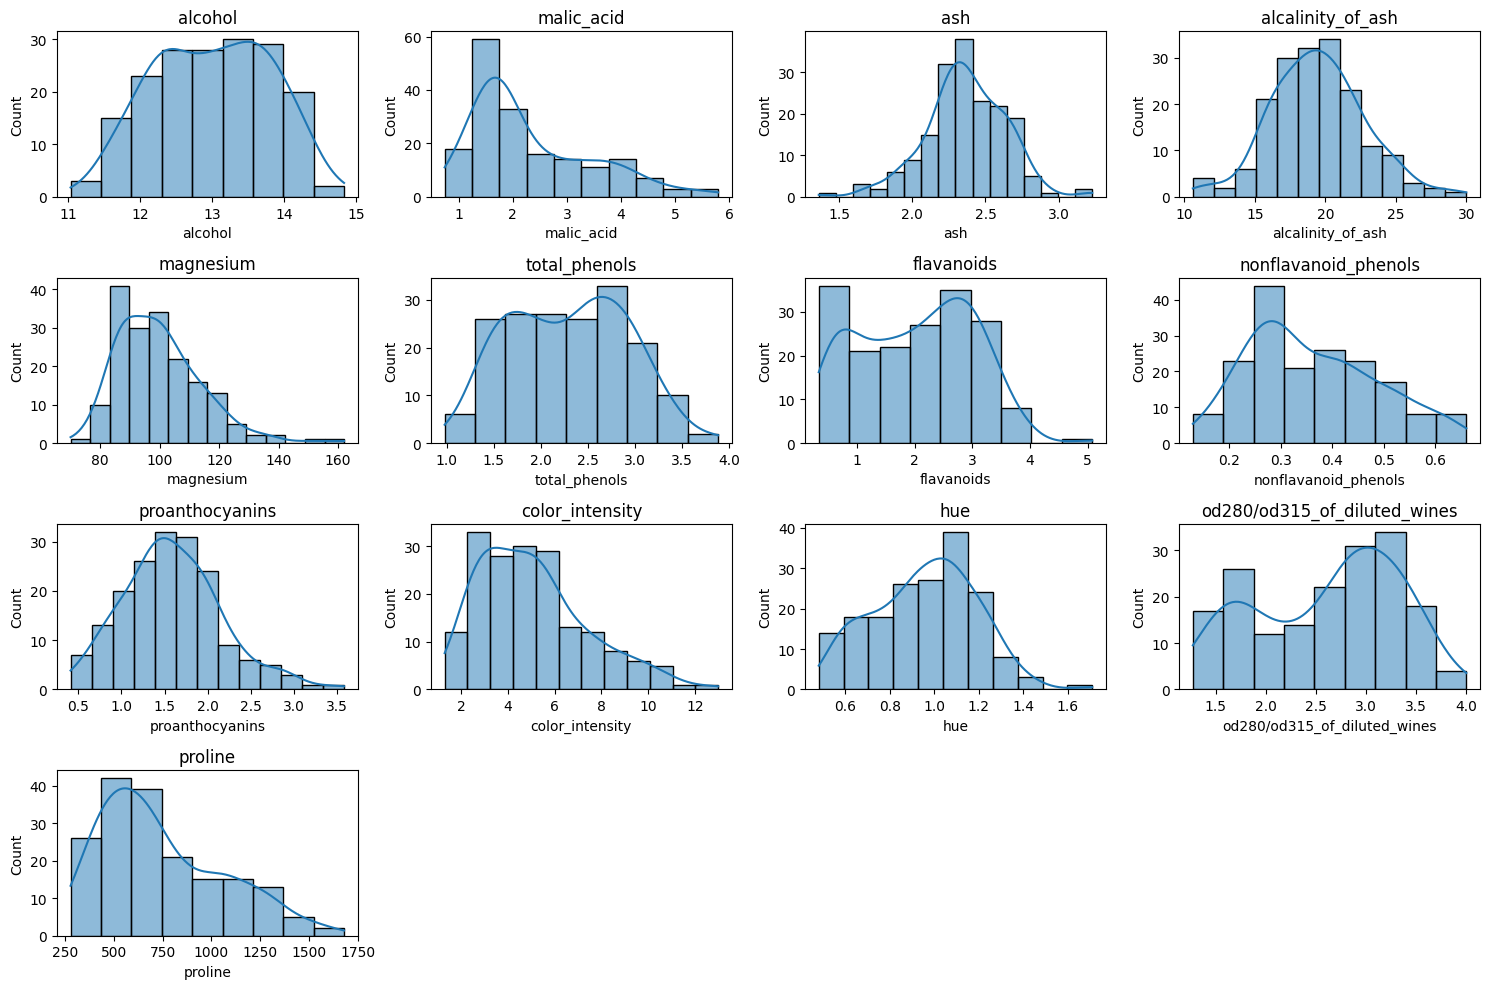

In [11]:
# histogram distribution of features
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(col)
plt.tight_layout()
plt.savefig('feature distribution.png')
plt.show()


| Feature                             | Distribution Shape           | Insight                          |
| ----------------------------------- | ---------------------------- | -------------------------------- |
| *alcohol*                         | Symmetrical, slightly skewed | Normal-like distribution         |
| *malic\_acid*                     | Right-skewed                 | Most wines have low malic acid   |
| *ash*                             | Nearly normal                | Centered around 2.5            |
| *alcalinity\_of\_ash*             | Symmetric                    | Slight peak near 20            |
| *magnesium*                       | Right-skewed                 | Most values are between 70–100   |
| *total\_phenols*                  | Fairly uniform               | Spread evenly from 1–3         |
| *flavonoids*                      | Right-skewed                 | Many wines with low values       |
| *nonflavanoid\_phenols*           | Right-skewed                 | Similar pattern to flavonoids    |
| *proanthocyanins*                 | Normal-like                  | Balanced spread                  |
| *color\_intensity*                | Right-skewed                 | Few very intense-colored wines   |
| *hue*                             | Bell-shaped                  | Typical range 0.8–1.2          |
| *od280/od315\_of\_diluted\_wines* | Bimodal                      | Two common groups of wines       |
| *proline*                         | Strongly right-skewed        | Few wines have very high proline |

---
*General Observations*

- Several variables (e.g., malic_acid, magnesium, proline) are right-skewed, meaning:

 - Most wines have low values

 - A few have very high values (potential outliers)

- Some features (e.g. ash, hue) are normally distributed or close to symmetric

- od280/od315_of_diluted_wines seems bimodal, suggesting two natural wine groups based on this feature

- The KDE curves help identify data trends and may guide transformations (e.g., log-scaling right-skewed variables)

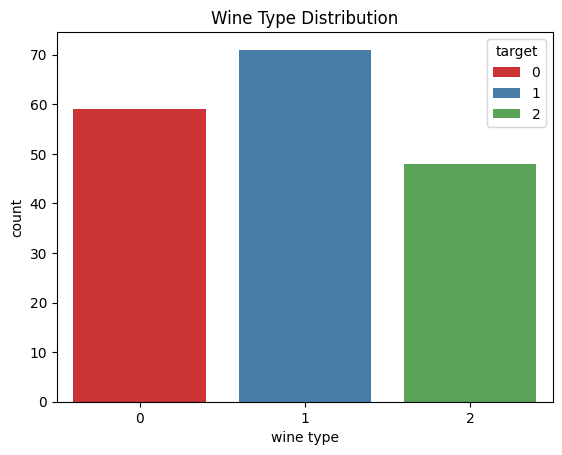

In [12]:
sns.countplot(data=df,x='target', palette='Set1',hue='target')
plt.title('Wine Type Distribution')
plt.xlabel('wine type')
plt.show()

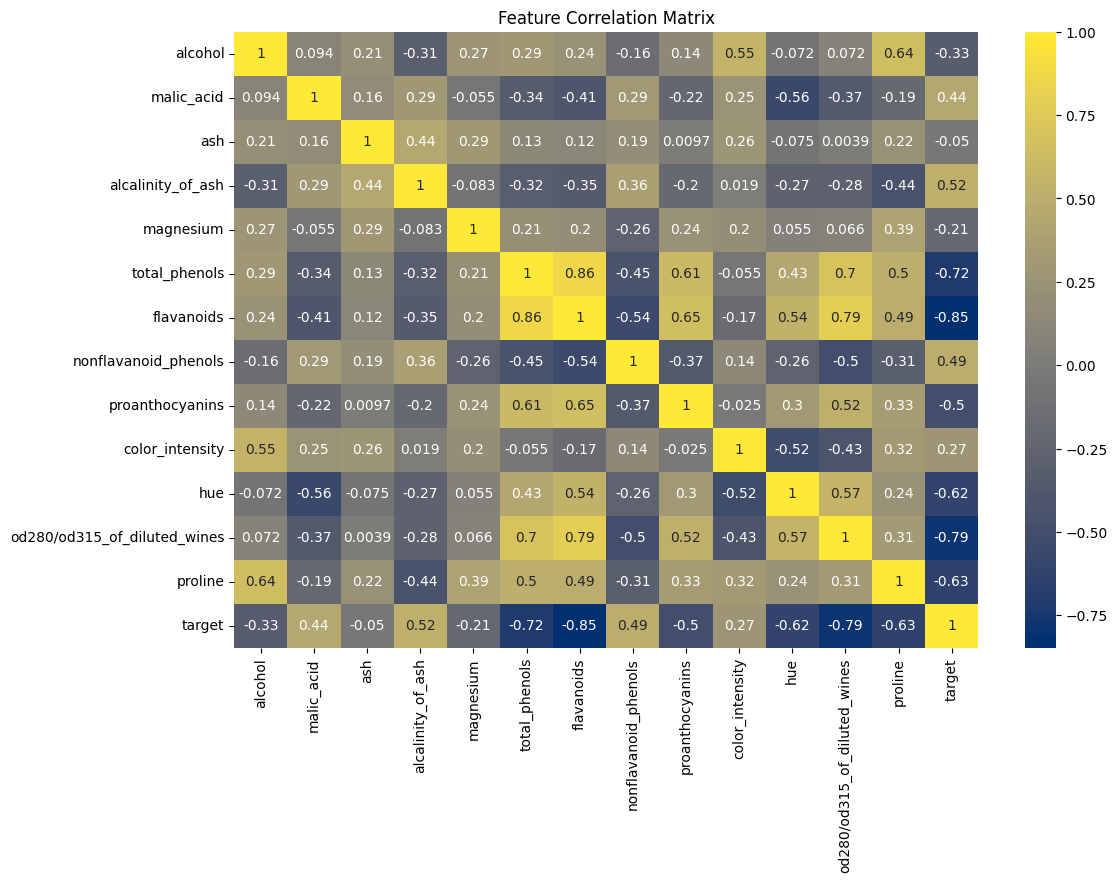

In [13]:
#correlation matrix
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='cividis', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig('Heatmap of wine features.png')
plt.show()

The strongest positive correlation is 0.86 between Total Phenols and Flavanoids. This suggests that as the flavanoid content in the wine increases, the total phenol content also tends to increase. These two features are likely related chemically, as flavanoids are a type of phenol.

The strongest negative correlation is -0.56 between Malic Acid and Hue. This means that wines with higher malic acid levels tend to have lower hue values (color tint), and vice versa. This inverse relationship may reflect differences in wine composition and acidity affecting the color characteristics.

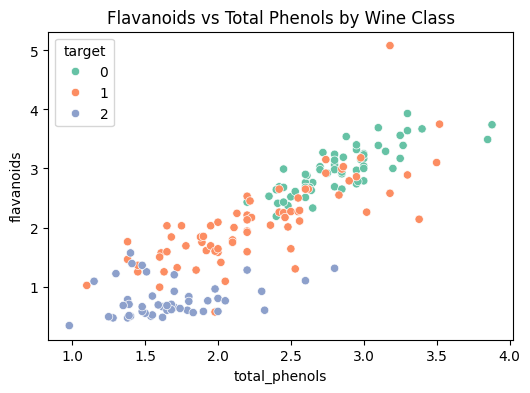

In [14]:

plt.figure(figsize=(6,4))
sns.scatterplot(x='total_phenols', y='flavanoids', hue='target', data=df, palette='Set2')
plt.title("Flavanoids vs Total Phenols by Wine Class")
plt.show()



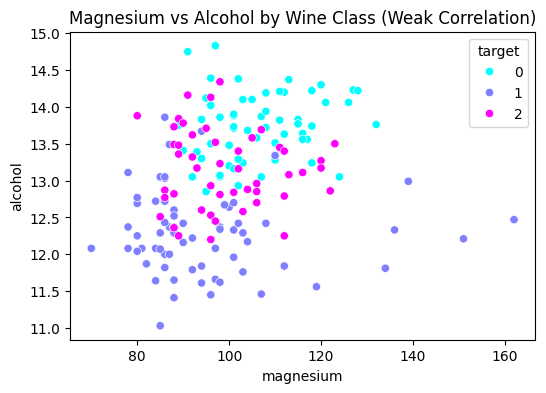

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='magnesium', y='alcohol', hue='target', data=df, palette='cool')
plt.title("Magnesium vs Alcohol by Wine Class (Weak Correlation)")
plt.show()


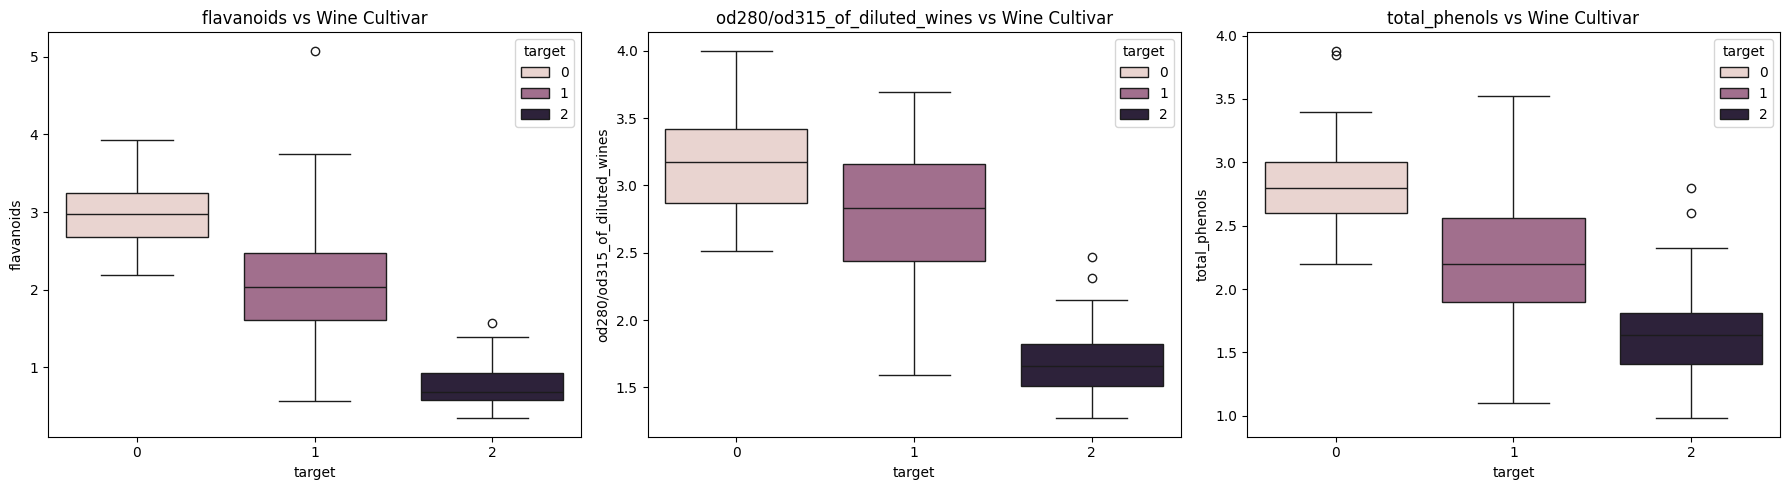

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

for i, col in enumerate(features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i],hue='target')
    axes[i].set_title(f'{col} vs Wine Cultivar')

plt.tight_layout()
plt.show()


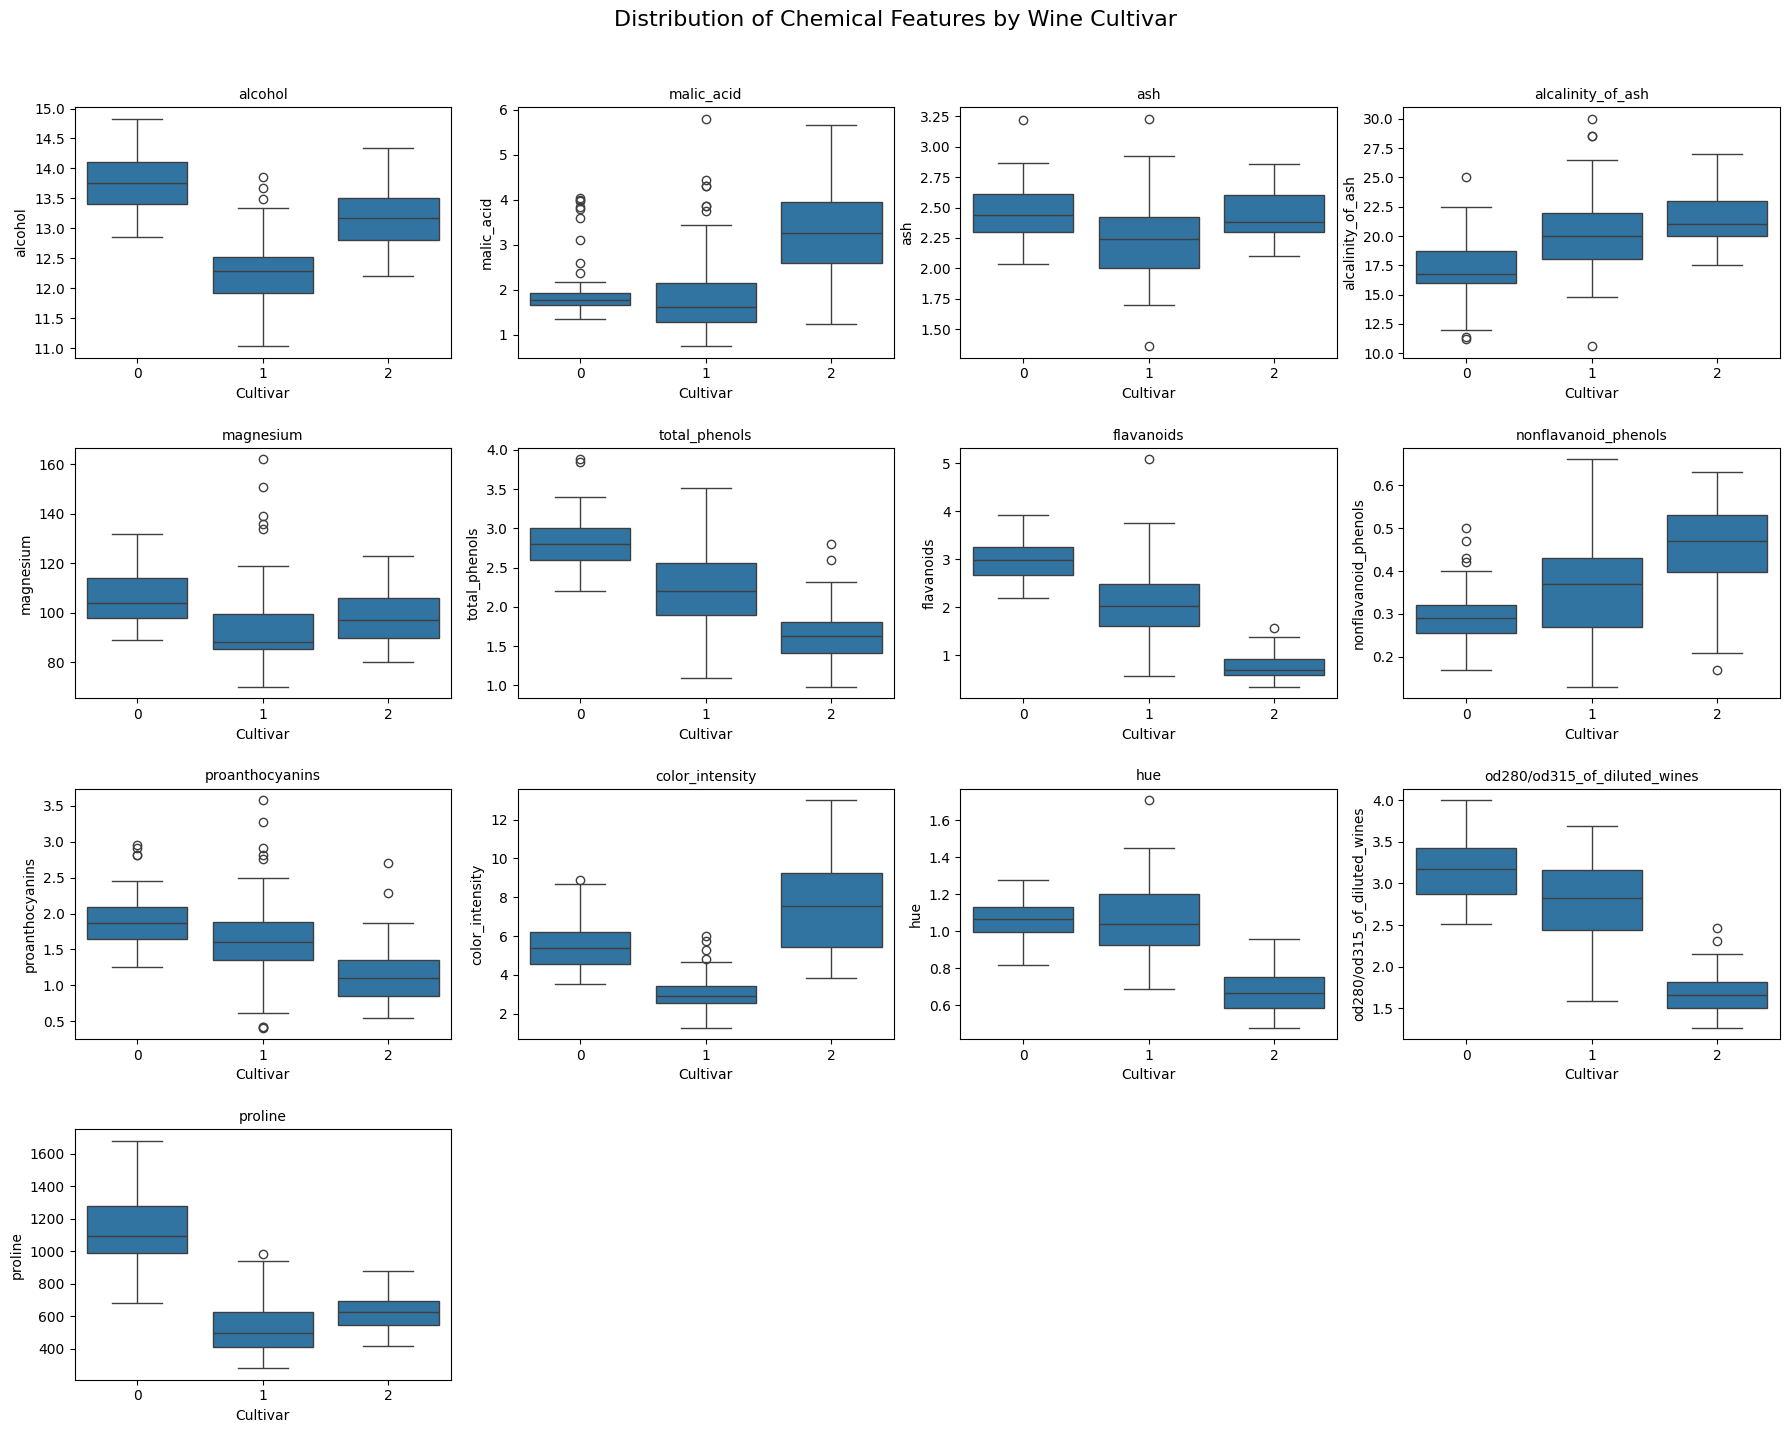

In [17]:


features = df.columns[:-1]  # all features except target
y = df['target']

plt.figure(figsize=(18, 14))  # Adjust height to make room for spacing

# Add suptitle
plt.suptitle('Distribution of Chemical Features by Wine Cultivar', fontsize=16, y=1.02)

for i, feature in enumerate(features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=y, y=df[feature])
    plt.title(f'{feature}', fontsize=10)
    plt.xlabel('Cultivar')
    plt.ylabel(feature)

plt.tight_layout(h_pad=2.0)
plt.show()

| Feature                  | Cultivar 0 🧪 | Cultivar 1 🧪   | Cultivar 2 🧪 | 🔍 Insight                               |
| ------------------------ | ------------- | --------------- | ------------- | ---------------------------------------- |
| *Proline*              | 🔼 High       | 🔽 Low          | ➖ Medium      | ✅ Strong — best for Cultivar 0           |
| *Color Intensity*      | ➖ Medium      | 🔽 Low          | 🔼 High       | ✅ Strong — clearly separates Cultivar 2  |
| *OD280/OD315*          | 🔼 High       | 🔼 High         | 🔽 Low        | ✅ Strong — identifies Cultivar 2         |
| *Hue*                  | ➖ Medium      | 🔼 High         | 🔽 Low        | ✅ Good for Cultivar 1 vs. 2              |
| *Flavanoids*           | 🔼 High       | ➖ Medium        | 🔽 Low        | ✅ Strong — separates Cultivar 0 and 2    |
| *Total Phenols*        | 🔼 High       | ➖ Medium        | 🔽 Low        | ✅ Strong — similar pattern as flavanoids |
| *Proanthocyanins*      | 🔼 High       | ➖ Medium        | 🔽 Low        | ✅ Helps separate Cultivar 0 and 2        |
| *Alcohol*              | 🔼 High       | 🔽 Low          | ➖ Medium      | ⚠ Moderate — separates Cultivar 1       |
| *Malic Acid*           | 🔽 Low        | ➖ Medium        | 🔼 High       | ⚠ Moderate — distinguishes 0 vs 2       |
| *Nonflavanoid Phenols* | 🔽 Low        | ➖ Medium        | 🔼 High       | ⚠ Moderate — some separation            |
| *Ash*                  | ➖ Overlap     | 🔽 Slightly Low | ➖ Overlap     | ❌ Weak — not very useful                 |
| *Alcalinity of Ash*    | 🔽 Low        | 🔼 High         | 🔼 High       | ❌ Weak — high variation                  |
| *Magnesium*            | ➖ Overlap     | ⚠ Outliers     | ➖ Overlap     | ❌ Weak — not a good separator            |

## Train and Evaluate using five classification models

In [18]:
# Defining X and y
X=df.drop('target',axis=1)
y=df['target']

In [19]:
# splitting and X features and y target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [20]:
# Training the Decision Tree model
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
# prediction models
y_pred=dt_model.predict(X_test)

In [22]:
target=data.target_names
target

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [23]:
# model evaluation

dt_classification_report= classification_report(y_test,y_pred,target_names=target)
print(dt_classification_report)

              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



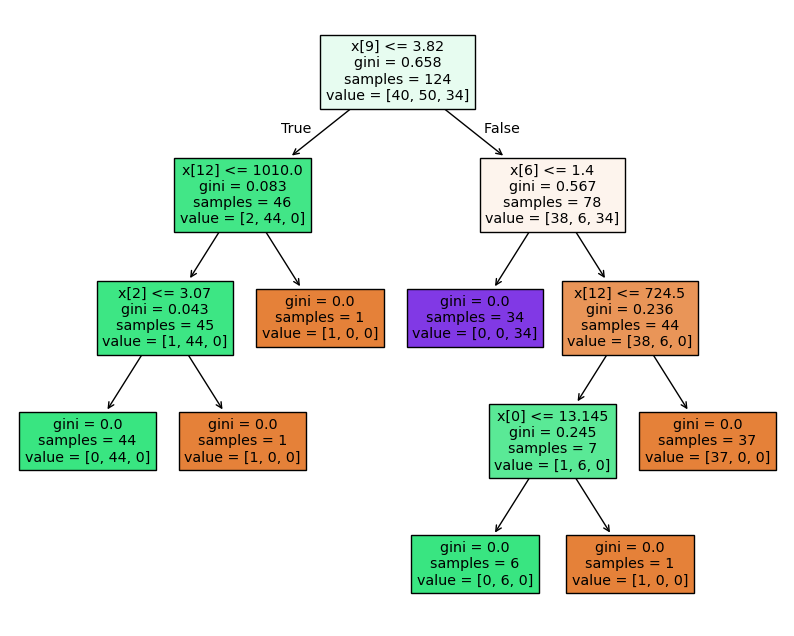

In [24]:
from sklearn import tree
plt.figure(figsize=(10,8))
tree.plot_tree(dt_model,filled=True)
plt.savefig('wine tree.png')
plt.show()

This decision tree classifier was trained on a dataset with three target classes. The tree splits the dataset based on various feature thresholds to classify the data accurately. Here’s how the model makes its decisions:

🔍 Overall Logic
	•	The model first examines feature x[9].
	•	If x[9] ≤ 3.82, the model mostly identifies the sample as Class 1.
	•	If x[9] > 3.82, the sample is further evaluated to distinguish between Class 0 and Class 2.

📗 Left Branch (x[9] ≤ 3.82)
	•	This branch is dominated by Class 1 observations.
	•	The model refines its decision using feature x[12] and then feature x[2], achieving near-perfect classification:
	•	44 out of 46 samples in this branch are correctly classified as Class 1.
	•	Only one misclassification appears as Class 0.

📘 Right Branch (x[9] > 3.82)
	•	This branch contains a mix of Class 0 and Class 2.
	•	The model checks feature x[6]:
	•	If x[6] ≤ 1.4, it accurately classifies the sample as Class 2 (with zero error).
	•	If x[6] > 1.4, it uses x[12] and then x[0] to separate Class 0 and Class 1:
	•	Most samples here are Class 0.
	•	A small group is correctly classified as Class 1.

🎯 Model Performance Highlights
	•	Most leaf nodes have a Gini index of 0, indicating pure classifications.
	•	The splits chosen by the model lead to highly confident predictions.
	•	The model successfully learns to distinguish between the three classes using a few key features.

## Random Forest

In [25]:
rf_model=RandomForestClassifier(oob_score=True,n_estimators=10,bootstrap=True,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, oob_score=True, random_state=42)

In [26]:
rf_y_pred=rf_model.predict(X_test)

rf_classification_report=classification_report(y_test,rf_y_pred,target_names=target)
print(rf_classification_report)

              precision    recall  f1-score   support

     class_0       0.90      1.00      0.95        19
     class_1       0.95      0.86      0.90        21
     class_2       0.93      0.93      0.93        14

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54



In [27]:
rf_confusion_matrix=confusion_matrix(y_test,rf_y_pred)
print(rf_confusion_matrix)

[[19  0  0]
 [ 2 18  1]
 [ 0  1 13]]


### Scaling the data

In [28]:
from sklearn.preprocessing import StandardScaler
#initialize the scaler
scaler=StandardScaler()
#fit and transfrom the values
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## KNN & Cross Validation

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

K_range=range(1,31)
scores=[]

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score= cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring='accuracy')
    scores.append(score.mean())

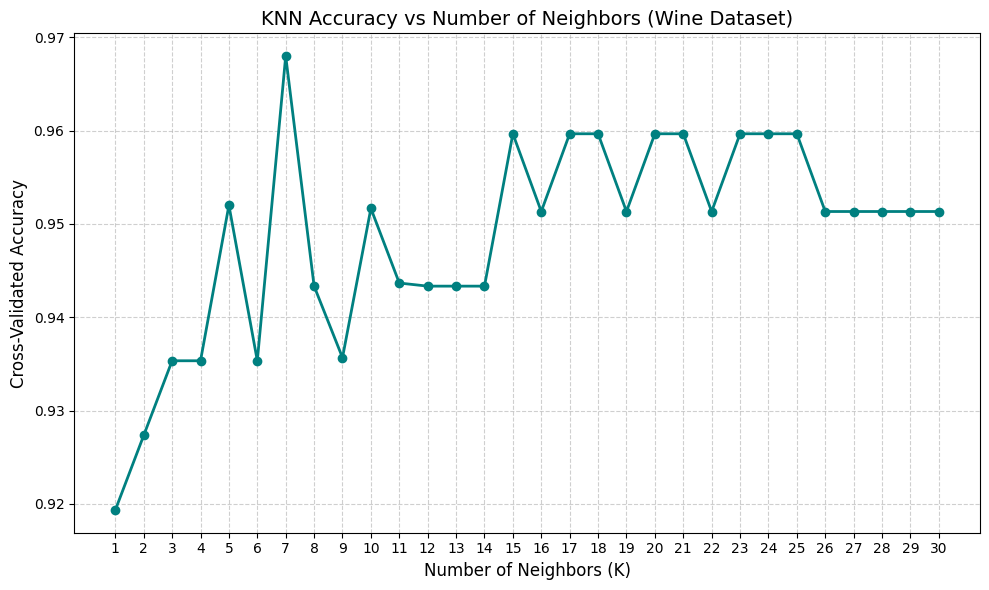

In [30]:
# visualizing cross validation scores vs No of neighbours

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(K_range, scores, marker='o', linestyle='-', color='teal', linewidth=2)

# Enhancements
plt.title('KNN Accuracy vs Number of Neighbors (Wine Dataset)', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Save the figure
plt.tight_layout()
plt.savefig("optimal_K_for_wine_dataset.png", dpi=300)
plt.show()


In [31]:
# finding the optimal K
optimal_k=K_range[np.argmax(scores)]
print(f"Optimal k value: {optimal_k}")

Optimal k value: 7


In [32]:
# modeling using the optimal K
knn_optimal=KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled,y_train)
y_pred_optimal=knn_optimal.predict(X_test_scaled)

In [33]:
KNN_report=classification_report(y_test,y_pred_optimal)
print(KNN_report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## Logistic Regression with RFE

In [34]:
from sklearn.feature_selection import RFE
logistic_model=LogisticRegression()
rfe=RFE(logistic_model, n_features_to_select=4)# applying RFE to only show the most important 5 features
rfe.fit(X_train_scaled, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=4)

In [35]:
# showing the five most important features
selected_features=X.columns[rfe.support_]
print(selected_features)

Index(['alcohol', 'flavanoids', 'hue', 'proline'], dtype='object')


In [36]:
# modifying X_train_scaled to the selected features
X_train_selected=X_train_scaled[:, rfe.support_]
X_test_selected=X_test_scaled[:, rfe.support_]

In [37]:
# applying the selected features to the regression model
logistic_model.fit(X_train_selected, y_train)
y_pred_logistic=logistic_model.predict(X_test_selected)

In [38]:
logistic_report=classification_report(y_test, y_pred_logistic)
print(logistic_report)
con_matrix_logistic=confusion_matrix(y_test, y_pred_logistic)
print(con_matrix_logistic)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.90      0.95        21
           2       0.88      1.00      0.93        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54

[[19  0  0]
 [ 0 19  2]
 [ 0  0 14]]


In [39]:
# without RFE
logistic_model.fit(X_train_scaled,y_train)
y_pred_logistic2=logistic_model.predict(X_test_scaled)

In [40]:
logistic_report2=classification_report(y_test, y_pred_logistic2)
print(logistic_report2)
con_matrix_logistic2=confusion_matrix(y_test, y_pred_logistic2)
print(con_matrix_logistic2)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        21
           2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

[[19  0  0]
 [ 0 20  1]
 [ 0  0 14]]


In [41]:
#using PCA

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

In [42]:
lr_model_pca=LogisticRegression()
lr_model_pca.fit(X_train_pca,y_train)

lr_pca_pred=lr_model_pca.predict(X_test_pca)

lr_pca_report=classification_report(y_test,lr_pca_pred)
print(lr_pca_report)

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.91      1.00      0.95        21
           2       1.00      1.00      1.00        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.97        54
weighted avg       0.97      0.96      0.96        54



In [43]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_tain_scaled_pca=pca.fit_transform(X_train_scaled)
X_test_scaled_pca=pca.transform(X_test_scaled)

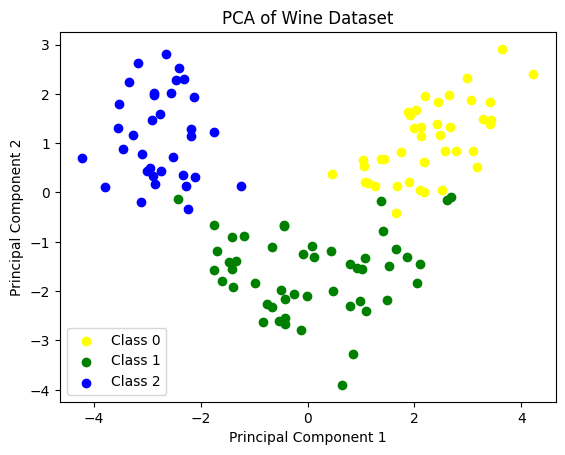

In [44]:
# Let's assume y_train has class labels: 0, 1, 2
colors = ['yellow', 'green', 'blue']
labels = [0, 1, 2]

for i, color in zip(labels, colors):
    plt.scatter(
        X_tain_scaled_pca[y_train == i, 0],
        X_tain_scaled_pca[y_train == i, 1],
        label=f'Class {i}',
        c=color
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Dataset')
plt.legend()
plt.show()

In [45]:
# Building the svm model using girdsearchcv to find the best params

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_model=SVC()

grid_params=[
    {'kernel':['Linear'],'C':[0.1,1,10,100]},
    {'kernel':['rbf'],'C':[0.1,1,10,100],'gamma':[0.01,0.1,1,10]}
]

grid_search=GridSearchCV(estimator=svm_model,param_grid=grid_params,scoring='accuracy',cv=5)
grid_search.fit(X_tain_scaled_pca,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100], 'kernel': ['Linear']},
                         {'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10],
                          'kernel': ['rbf']}],
             scoring='accuracy')

In [46]:
print("Best params",grid_search.best_params_)
print("Best score",grid_search.best_score_)

Best params {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best score 0.9676666666666666


In [47]:
y_gridsearchPrediction=grid_search.predict(X_test_scaled_pca)

grid_search_classification_report=classification_report(y_test,y_gridsearchPrediction,target_names=target)
print(grid_search_classification_report)

              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [48]:
def decision_boundary(model,X,y):
  X_min,X_max=X[:,0].min()-1,X[:,0].max()+1
  Y_min,Y_max=X[:,1].min()-1,X[:,1].max()+1
  step=0.01
  x_mesh,y_mesh=np.meshgrid(np.arange(X_min,X_max,step),np.arange(Y_min,Y_max,step))
  Z=model.predict(np.c_[x_mesh.ravel(),y_mesh.ravel()])
  Z=Z.reshape(x_mesh.shape)


  plt.figure(figsize=(10,6))
  plt.contourf(x_mesh,y_mesh,Z,alpha=0.4,cmap='coolwarm')
  plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',edgecolors='k')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.title('Decision Boundary')

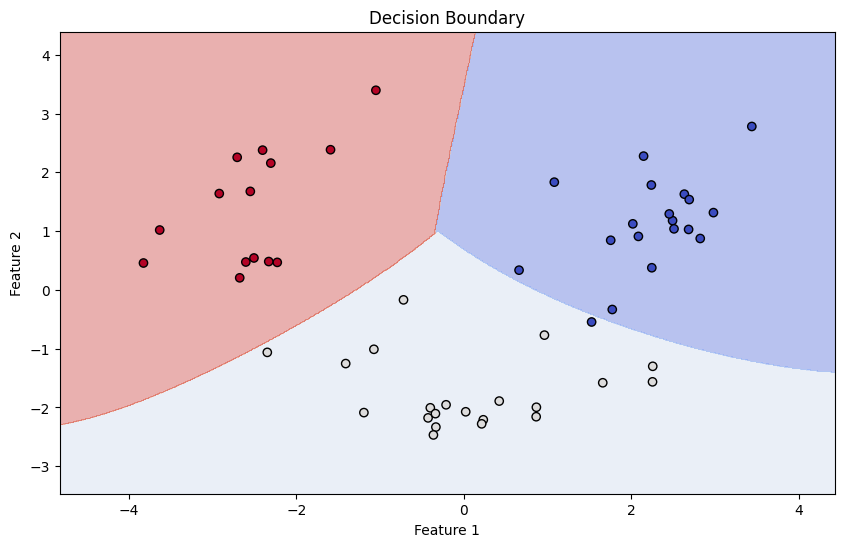

In [49]:
#decision boundary for rbf
decision_boundary(grid_search,X_test_scaled_pca,y_test)

In [50]:
#Classification report comparison
print(f"Decision Tree Classification Report:\n{dt_classification_report}")
print(f"Random Forest Classification Report:\n{rf_classification_report}")
print(f"KNN Classification Report:\n{KNN_report}")
print(f"Logistic Regression Classification Report:\n{logistic_report}")
print(f"Logistic Regression Classification Report (without RFE):\n{logistic_report2}")
print(f"PCA Logistic Regression Classification Report:\n{lr_pca_report}")
print(f"SVM Classification Report:\n{grid_search_classification_report}")


Decision Tree Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54

Random Forest Classification Report:
              precision    recall  f1-score   support

     class_0       0.90      1.00      0.95        19
     class_1       0.95      0.86      0.90        21
     class_2       0.93      0.93      0.93        14

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00     